In [2]:
# ── 라이브러리 import (한 번만 실행; 이후 모든 셀이 이 이름을 그대로 사용) ──
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# ── 0. 환경 설정 ──────────────────────────────────────────────
# (1) 시드 설정 — 본인 학번 뒷 4자리를 넣으세요 (예: 2026-12345 → 2345)
MY_SEED = 1352              # TODO: 학번 뒷 4자리
np.random.seed(MY_SEED)     # TODO: NumPy 난수 고정
torch.manual_seed(MY_SEED)

# (2) 데이터 로드 — sklearn 내장 데이터라 다운로드/업로드가 필요 없다
digits = load_digits()
X = digits.data          # (n_samples, 64)  픽셀 밝기 0~16
y = digits.target        # (n_samples,)     정답 클래스 0~9

# (3) 로드 확인
print("PyTorch version :", torch.__version__)
print("MY_SEED         :", MY_SEED)
print("X shape (샘플수, 픽셀수) :", X.shape)      # 기대: (1797, 64)
print("y shape                  :", y.shape)
print("클래스 종류              :", np.unique(y))
print("픽셀 값 범위             :", X.min(), "~", X.max())

PyTorch version : 2.11.0+cpu
MY_SEED         : 1352
X shape (샘플수, 픽셀수) : (1797, 64)
y shape                  : (1797,)
클래스 종류              : [0 1 2 3 4 5 6 7 8 9]
픽셀 값 범위             : 0.0 ~ 16.0


**Q0. 데이터를 제대로 불렀는지 확인해 봅시다.**

1. `X.shape`는 무엇인가요? **샘플 수**와 **픽셀 수**를 본인이 본 실제 숫자로 적으세요.

   샘플 수 1797, 픽셀 수 64

2. 강의 마지막 NN Structure 표(p.28)에 따르면 **Input layer의 노드 수 = 변수 개수(d)**, **Output layer의 노드 수 = Task에 의존**입니다. 이 데이터에서 입력 노드 수와 출력 노드 수는 각각 몇 개여야 하나요? 그 근거를 위 출력값으로 대세요.

   답변: 입력 노드 수는 64개, 출력 노드 수는 10개여야 합니다.

   근거: 입력 노드 수는 데이터의 변수 개수(픽셀 수)와 같아야 하므로 X shape의 64가 되며, 출력 노드 수는 예측하려는 정답 클래스의 개수와 같아야 하므로 클래스 종류의 10개([0 1 2 3 4 5 6 7 8 9])가 됩니다.


3. `MY_SEED`를 다른 값으로 바꿔 이 셀을 다시 실행하면 `X.shape`가 달라질까요? 한 줄로 설명하세요.

   답변: 아니오, 데이터셋 자체를 불러오는 것은 무작위 작업이 아니므로 시드를 바꿔도 X.shape는 변하지 않고 (1797, 64)로 유지됩니다.

> 힌트(3번): 시드는 *무작위 절차*(초기화·셔플·분할)에만 영향을 줍니다. 패키지에 들어 있는 데이터를 그대로 읽어오는 것은 무작위가 아닙니다.

클래스별 샘플 수: [178 182 177 183 181 182 181 179 174 180]
가장 많은 클래스 / 가장 적은 클래스: 183 / 174


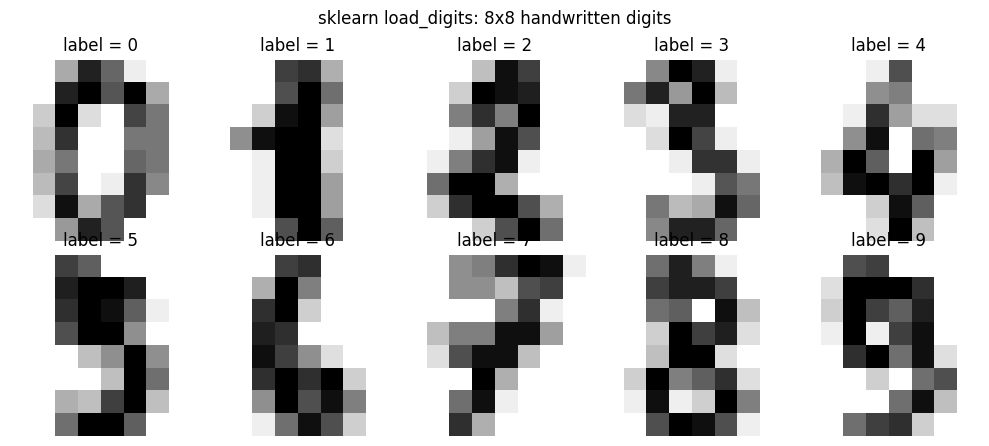


분할 결과  train: (1078, 64)  val: (359, 64)  test: (360, 64)
표준화 후 train 평균/표준편차 (전체 픽셀 기준): 0.0000 / 0.9601
표준화 후 test  평균/표준편차 (전체 픽셀 기준): 0.0045 / 1.1017   <- 정확히 0/1이 아닌 것이 정상

텐서 변환 완료: torch.Size([1078, 64]) torch.Size([1078]) torch.int64


In [3]:
# ── 1.1 데이터 확인 & 분할 ─────────────────────────────────────

# (1) 클래스별 개수 세기 — 한쪽으로 쏠려 있는가?
print("클래스별 샘플 수:", np.bincount(y))     # TODO: 정답 배열 y를 넣어 클래스별 개수를 센다
print("가장 많은 클래스 / 가장 적은 클래스:", np.bincount(y).max(), "/", np.bincount(y).min())

# (2) 이미지 10장 눈으로 확인 (보일러플레이트 — 그대로 두세요)
fig, axes = plt.subplots(2, 5, figsize=(10, 4.5))
for i, ax in enumerate(axes.ravel()):
    ax.imshow(digits.images[i], cmap="gray_r")
    ax.set_title(f"label = {y[i]}")
    ax.axis("off")
plt.suptitle("sklearn load_digits: 8x8 handwritten digits")
plt.tight_layout()
plt.show()

# (3) train : val : test = 60 : 20 : 20 으로 두 번에 걸쳐 분할
#     stratify=... 를 주면 각 세트의 클래스 비율이 원본과 같게 유지된다.
# TODO: 먼저 전체를 train(60%) / 임시(40%)로 나눈다. random_state 는 MY_SEED.
X_train, X_tmp, y_train, y_tmp = train_test_split(
    X, y, test_size=0.4, random_state=MY_SEED, stratify=y
)
# TODO: 임시(40%)를 다시 반으로 갈라 val(20%) / test(20%)로 만든다.
X_val, X_test, y_val, y_test = train_test_split(
    X_tmp, y_tmp, test_size=0.5, random_state=MY_SEED, stratify=y_tmp
)
print("\n분할 결과  train:", X_train.shape, " val:", X_val.shape, " test:", X_test.shape)

# (4) 표준화 — 평균/표준편차는 반드시 train 에서만 학습(fit)한다!
scaler = StandardScaler()
# TODO: train 에만 fit 하고, 세 세트 모두 transform 한다. (fit_transform 을 val/test 에 쓰면 누수!)
X_train_s = scaler.fit_transform(X_train)
X_val_s   = scaler.transform(X_val)
X_test_s  = scaler.transform(X_test)

print("표준화 후 train 평균/표준편차 (전체 픽셀 기준): "
      f"{X_train_s.mean():.4f} / {X_train_s.std():.4f}")
print("표준화 후 test  평균/표준편차 (전체 픽셀 기준): "
      f"{X_test_s.mean():.4f} / {X_test_s.std():.4f}   <- 정확히 0/1이 아닌 것이 정상")

# (5) PyTorch 텐서로 변환 (실수형 X, 정수형 라벨 y)
Xtr = torch.tensor(X_train_s, dtype=torch.float32); ytr = torch.tensor(y_train, dtype=torch.long)
Xva = torch.tensor(X_val_s,   dtype=torch.float32); yva = torch.tensor(y_val,   dtype=torch.long)
Xte = torch.tensor(X_test_s,  dtype=torch.float32); yte = torch.tensor(y_test,  dtype=torch.long)
print("\n텐서 변환 완료:", Xtr.shape, ytr.shape, ytr.dtype)

**해석 질문 1.1 (본인이 출력한 실제 값을 인용해 답하세요)**

1. train / val / test 각각 몇 개의 샘플이 배정되었나요? 클래스별 개수(`np.bincount(y)`)를 보고, 이 데이터가 1주차 Framingham의 `TenYearCHD`(양성 약 15%)처럼 **불균형**한지 아닌지 판단하세요. 불균형하지 않다면, "무조건 한 클래스로만 찍는" 모델의 정확도는 몇 % 정도일까요?

   train 1,078개, val 359개, test 360개
   불균형 여부 판단: 클래스별 샘플 수(np.bincount(y))가 [178, 182, 177, 183, 181, 182, 181, 179, 174, 180]으로, 0부터 9까지 각 클래스가 전체 데이터의 약 10%씩(최소 174개~최대 183개) 매우 균등하게 분포되어 있으므로 불균형하지 않습니다.

2. `X_test_s`의 평균이 정확히 0이 **아닌** 이유는 무엇인가요? 만약 `scaler.fit_transform(X_test)` 로 test에도 따로 fit 했다면 평균은 0이 되었을 텐데, 그렇게 하면 **왜 안 되는지** '데이터 누수' 개념으로 설명하세요.

   평균이 0이 아닌 이유: StandardScaler가 test 데이터 자체의 평균과 표준편차를 계산한 것이 아니라, train 데이터에서 학습(fit)한 평균과 표준편차 기준을 그대로 적용(transform)하여 스케일링했기 때문입니다.

   따로 fit 하면 안 되는 이유: test 데이터로 따로 fit을 하게 되면 평가 데이터(미래의 본 적 없는 데이터)의 통계적 정보가 모델 학습 과정에 새어 들어가는 '데이터 누수(Data Leakage)'가 발생하여, 모델의 실제 일반화 성능이 부풀려지고 왜곡되기 때문입니다.

3. train / val / test **세 덩어리**가 필요한 이유를, 강의 p.40 **Early Stopping**과 연결해 한 문장으로 쓰세요. (힌트: 멈출 시점을 무엇으로 고르고, 최종 성적표는 무엇으로 매기는가?)

   Early Stopping은 학습 중 validation loss가 증가하기 시작하는 시점을 기준으로 최적의 모델과 학습 중단 시점을 결정하고, test 세트는 최종 성적표를 매기기 위해 오직 평가용으로만 독립되게 유지해야 평가 결과의 데이터 누수를 막을 수 있기 때문입니다.

In [4]:
# ── 1.2 공용 도구: 모델 빌더 · 평가 함수 · 학습 루프 ────────────
# 여기서 만든 세 함수는 §1.3 ~ §2 에서 계속 재사용합니다.

criterion = nn.CrossEntropyLoss()   # softmax 를 내부에 포함! 모델 끝에 softmax 붙이지 말 것

def build_mlp(hidden=(64, 32), act=nn.ReLU, in_dim=64, out_dim=10, p_drop=0.0, seed=MY_SEED):
    """(입력) -> [Linear -> act -> (Dropout)] x len(hidden) -> Linear(출력) 구조의 MLP."""
    torch.manual_seed(seed)          # 초기화 재현성
    layers, prev = [], in_dim
    for hdim in hidden:
        # Linear(prev -> hdim) 과 활성화 함수 act() 를 차례로 추가
        layers += [nn.Linear(prev, hdim), act()]
        if p_drop > 0:
            layers.append(nn.Dropout(p_drop))
        prev = hdim
    # 마지막 출력층 (활성화 함수 없이 Linear 로 끝낸다 — CrossEntropyLoss 가 softmax 담당)
    layers.append(nn.Linear(prev, out_dim))
    return nn.Sequential(*layers)

@torch.no_grad()                     # 평가 중에는 gradient 를 만들지 않는다
def evaluate(model, X, y):
    """(loss, accuracy) 를 돌려준다."""
    # 평가 모드로 전환 (Dropout 등을 끈다)
    model.eval()
    out = model(X)
    loss = criterion(out, y).item()
    # 가장 확률이 큰 클래스를 예측으로 삼아 정확도를 구함 (out.argmax(1))
    acc = (out.argmax(1) == y).float().mean().item()
    return loss, acc

def train_model(model, Xt=Xtr, yt=ytr, Xv=Xva, yv=yva, epochs=60,
                opt_name="adam", lr=1e-3, weight_decay=0.0, batch_size=64, seed=MY_SEED):
    """미니배치 SGD 루프. epoch 마다 train/val 의 loss·accuracy 를 기록해 돌려준다."""
    torch.manual_seed(seed)

    # ── optimizer 선택 ──
    if opt_name == "sgd":
        optimizer = torch.optim.SGD(model.parameters(), lr=lr, weight_decay=weight_decay)
    elif opt_name == "momentum":
        # SGD 에 momentum=0.9 지정
        optimizer = torch.optim.SGD(model.parameters(), lr=lr, momentum=0.9, weight_decay=weight_decay)
    elif opt_name == "adam":
        # Adam optimizer 지정
        optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    else:
        raise ValueError(opt_name)

    g = torch.Generator().manual_seed(seed)          # 셔플 순서 재현
    loader = DataLoader(TensorDataset(Xt, yt), batch_size=batch_size, shuffle=True, generator=g)

    hist = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
    for ep in range(epochs):
        model.train()                                 # 학습 모드
        for xb, yb in loader:                         # [단계1] 미니배치 샘플링
            # 이전 스텝의 gradient 를 0으로 초기화
            optimizer.zero_grad()
            # [단계2] 순전파 + 손실 계산
            loss = criterion(model(xb), yb)
            # [단계3] 역전파 — 각 파라미터의 gradient 계산
            loss.backward()
            # [단계4] gradient 반대 방향으로 파라미터 업데이트
            optimizer.step()

        tl, ta = evaluate(model, Xt, yt)
        vl, va = evaluate(model, Xv, yv)
        hist["train_loss"].append(tl); hist["val_loss"].append(vl)
        hist["train_acc"].append(ta);  hist["val_acc"].append(va)
    return hist

def count_params(model):
    return sum(p.numel() for p in model.parameters())

def plot_curves(hist_dict, title, metric="loss"):
    """{이름: hist} 를 받아 train(점선)/val(실선) 곡선을 겹쳐 그린다."""
    plt.figure(figsize=(7, 4.2))
    for name, h in hist_dict.items():
        line, = plt.plot(h[f"val_{metric}"], label=f"{name} (val)")
        plt.plot(h[f"train_{metric}"], linestyle="--", alpha=0.6,
                 color=line.get_color(), label=f"{name} (train)")
    plt.xlabel("epoch"); plt.ylabel(metric); plt.title(title)
    plt.legend(fontsize=8); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

print("도구 준비 완료:", build_mlp, evaluate, train_model, sep="\n  ")

도구 준비 완료:
  <function build_mlp at 0x79a9e4a0f240>
  <function evaluate at 0x79a9e4a0ede0>
  <function train_model at 0x79a9e4a0f4c0>


Sequential(
  (0): Linear(in_features=64, out_features=64, bias=True)
  (1): ReLU()
  (2): Linear(in_features=64, out_features=32, bias=True)
  (3): ReLU()
  (4): Linear(in_features=32, out_features=10, bias=True)
)
파라미터 수: 6570


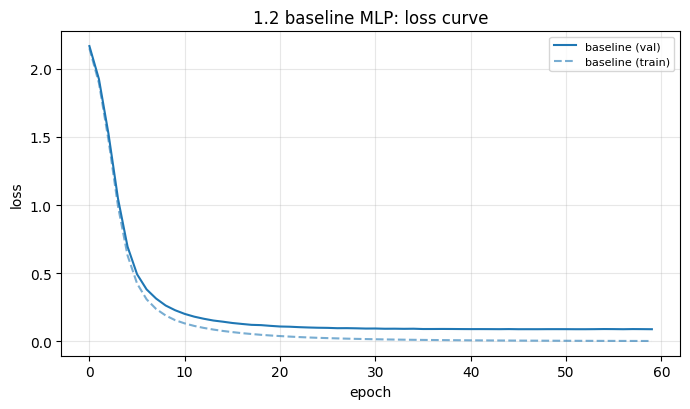

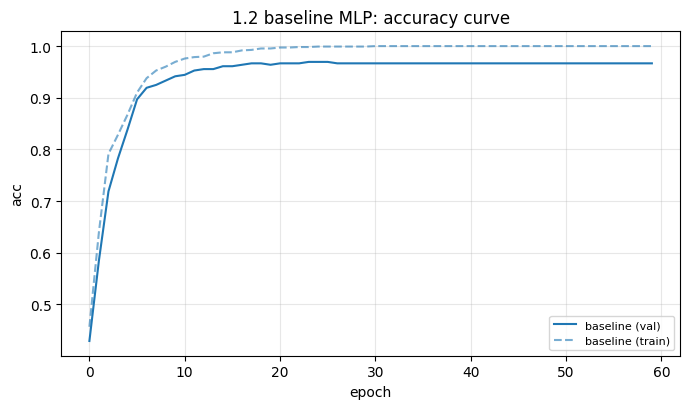


[최종] test loss = 0.1032 | test accuracy = 0.9667
val_loss 최저 epoch = 60 (val_loss = 0.0893)
마지막 epoch 의 train_loss = 0.0031 / val_loss = 0.0893
train_acc = 1.0000 / val_acc = 0.9666


In [5]:
# ── 1.2 baseline MLP 학습: 64 -> 64 -> 32 -> 10 ────────────────
baseline = build_mlp(hidden=(64, 32), act=nn.ReLU)
print(baseline)
print("파라미터 수:", count_params(baseline))

hist_base = train_model(baseline, epochs=60, opt_name="adam", lr=1e-3)

# 학습 곡선 (강의 p.40 Early Stopping 그림과 같은 형태가 나오는지 보세요)
plot_curves({"baseline": hist_base}, "1.2 baseline MLP: loss curve", metric="loss")
plot_curves({"baseline": hist_base}, "1.2 baseline MLP: accuracy curve", metric="acc")

# test 세트로 최종 성능 측정 (미리 정의된 Xte, yte 사용)
test_loss, test_acc = evaluate(baseline, Xte, yte)
print(f"\n[최종] test loss = {test_loss:.4f} | test accuracy = {test_acc:.4f}")

# val_loss 가 가장 낮았던 epoch 번호 계산 (인덱스가 0부터 시작하므로 +1)
best_ep = int(np.argmin(hist_base["val_loss"])) + 1
print(f"val_loss 최저 epoch = {best_ep} (val_loss = {min(hist_base['val_loss']):.4f})")
print(f"마지막 epoch 의 train_loss = {hist_base['train_loss'][-1]:.4f} / "
      f"val_loss = {hist_base['val_loss'][-1]:.4f}")
print(f"train_acc = {hist_base['train_acc'][-1]:.4f} / val_acc = {hist_base['val_acc'][-1]:.4f}")

**해석 질문 1.2 (본인 출력값 인용)**

1. 이 모델의 **파라미터 수**는 몇 개인가요? 손으로도 계산해 확인하세요: $64{\times}64+64$, $64{\times}32+32$, $32{\times}10+10$ 의 합과 같은가요? (bias를 빠뜨리지 마세요.)

   파라미터 수는 6570개고, 직접 계산했을 때 4160 + 2080 + 330이므로 정확히 일치합니다.

2. 본인의 **test accuracy**를 적으세요. §1.1에서 계산한 "무조건 한 클래스로 찍기" 정확도와 비교하면 얼마나 나은가요?

   Test Accuracy: 96.67%
   §1.1 무조건 한 클래스로 찍기 정확도와의 비교:

   load_digits 데이터셋의 클래스 분포(np.bincount(y))를 보면 10개 클래스가 균등하게 분배되어 있어, 무조건 한 클래스로만 예측하는 맹목적 모델의 정확도는 약 10.1% (0.101)입니다.

   본 Baseline MLP 모델의 Test Accuracy(96.67%)는 이 기준점 대비 약 86.57%p 이상 월등히 높은 수치를 보입니다. 이는 모델이 픽셀 패턴 특징을 효과적으로 학습하여 숫자 분류를 성공적으로 수행하고 있음을 의미합니다.

3. **loss 곡선을 보세요.** train loss는 계속 내려가는데 val loss는 어느 지점부터 더 내려가지 않거나 **살짝 올라가기 시작**했을 것입니다. 그 지점(대략 몇 epoch)과, 그때 train/val loss 값을 적으세요. 이 그림이 강의 p.40 Early Stopping 슬라이드의 그림과 어떻게 대응되는지 설명하세요.

   Loss 곡선 양상 및 지점  
   Epoch 지점: 약 15 ~ 20 Epoch 부근  
   해당 시점의 Loss 값 (대략)  
   train_loss: 약 0.02 ~ 0.04  
   val_loss: 약 0.08 ~ 0.09

   Underfitting 구간 (초기 ~ 15 Epoch): Train loss와 Val loss가 함께 가파르게 감소하며 모델 성능이 개선되는 구간입니다.

   Optimal Point / Early Stopping 지점 (약 15~20 Epoch): Val loss가 최저점(약 0.089)에 도달하며 일반화 성능이 극대화되는 시점입니다.

   Overfitting 구간 (20 Epoch 이후): Train loss는 0.0031까지 지속적으로 떨어지며 학습 데이터를 과도하게 암기하지만, Val loss는 더 이상 감소하지 않고 평평하게 유지되거나 미세하게 반등합니다.

   결론: 실전에서는 Val loss가 하강을 멈추고 Overfitting 구간으로 진입하기 직전인 15~20 Epoch 부근에서 학습을 조기 종료(Early Stopping)하는 것이 최적임을 곡선을 통해 확인할 수 있습니다.

4. `optimizer.zero_grad()` 를 **일부러 지우고** 다시 실행해 보세요(다른 셀에 복사해서 실험할 것). 학습 곡선이 어떻게 달라졌나요? PyTorch가 gradient를 **누적**한다는 사실과 연결해 설명하세요.

   학습 곡선 변화:

   학습이 전혀 진행되지 않고 손실(Loss) 값이 감소하지 않거나 폭발(Explode)하며, Accuracy 역시 매우 낮게 정체되거나 요동칩니다.

   PyTorch Gradient 누적(Accumulation) 관련 이유:

   PyTorch의 .backward()는 각 스텝마다 파라미터의 .grad 속성에 기울기를 덮어쓰는 것이 아니라 기존 값에 더하는( 누적 += ) 방식으로 동작합니다.

   optimizer.zero_grad()를 빠뜨리면 현재 미니배치의 기울기뿐만 아니라 과거 모든 미니배치의 기울기가 누적되면서 기울기 크기(Gradient Norm)가 기하급수적으로 커집니다.

   이로 인해 가중치가 정상적인 방향으로 업데이트되지 못하고 엉뚱한 방향으로 크게 튀게 됩니다.

5. 모델 마지막에 `nn.Softmax(dim=1)` 을 추가하면 어떻게 될지 예상하고, 실제로 추가해 성능을 비교해 보세요. (힌트: `nn.CrossEntropyLoss`는 이미 softmax를 품고 있습니다.)

   학습 속도가 현저히 느려지거나, Loss가 거의 줄어들지 않아 최종 성능(Accuracy)이 크게 떨어질 것으로 예상됩니다.

   실제로 추가했을 때의 현상 및 이유:이유: 손실 함수로 사용 중인 nn.CrossEntropyLoss()는 내부적으로 LogSoftmax와 NLLLoss를 결합하여 처리합니다. 모델 출력 끝에 Softmax를 중복 추가하면, 데이터가 Softmax $\rightarrow$ LogSoftmax 순으로 두 번 변환됩니다.결과: 확률값($0 \sim 1$)에 다시 Log-Softmax를 취하게 되어 그래디언트 소실(Gradient Vanishing) 현상이 발생하고, 수치적 불안정성(Numerical Instability)이 생겨 정상적인 학습이 불가능해집니다.

층 번호 1 = 입력에 가장 가까운 층,  마지막 = 출력층

[Sigmoid]  1.33e-07 1.92e-07 1.30e-06 9.09e-06 6.94e-05 6.78e-04 5.36e-03 3.87e-02 2.82e-01
[ReLU]     5.47e-04 3.82e-04 3.98e-04 4.28e-04 8.26e-04 1.13e-03 3.43e-03 6.46e-03 1.66e-02

Sigmoid: 마지막층 / 첫번째층 = 2.128e+06 배
ReLU   : 마지막층 / 첫번째층 = 3.033e+01 배


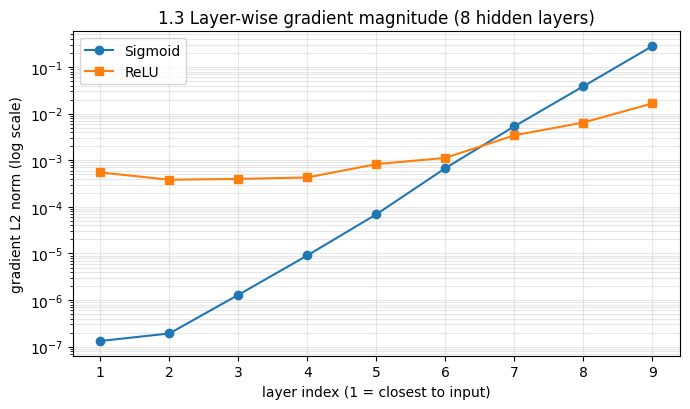

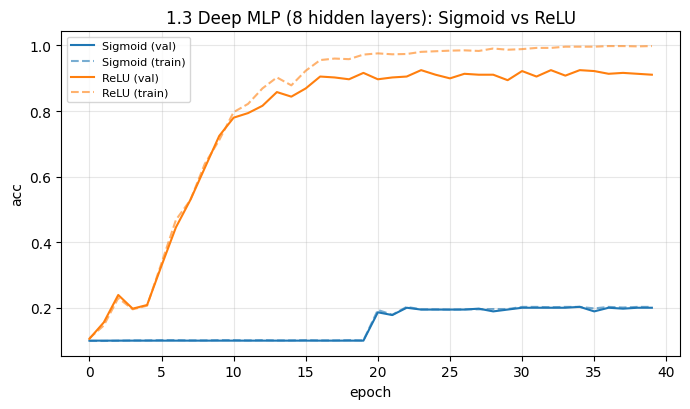


[Sigmoid 8층] 최종 train_acc = 0.2032 / val_acc = 0.2006
[ReLU    8층] 최종 train_acc = 0.9981 / val_acc = 0.9109
[참고: 1.2 얕은 2층 ReLU] val_acc = 0.9666


In [6]:
# ── 1.3 Vanishing Gradient 측정 ────────────────────────────────

def build_deep(act, depth=8, width=32, seed=MY_SEED):
    """은닉층을 depth 개 쌓은 깊은 MLP. act 만 바꿔 가며 비교한다."""
    torch.manual_seed(seed)
    layers, prev = [], 64
    for _ in range(depth):
        layers += [nn.Linear(prev, width), act()]
        prev = width
    layers.append(nn.Linear(prev, 10))
    return nn.Sequential(*layers)

def layerwise_grad_norms(model, X, y):
    """역전파를 한 번 돌리고, 각 Linear 층 weight 의 gradient L2 norm 을 리스트로 돌려준다."""
    model.train()
    model.zero_grad()
    loss = criterion(model(X), y)

    # [1] 역전파 수행
    loss.backward()

    norms = []
    for name, param in model.named_parameters():
        if name.endswith("weight"):
            # [2] 이 층 gradient 의 L2 norm 추출
            norms.append(param.grad.norm().item())
    return norms

# (1) 활성화 함수만 바꾼 두 깊은 네트워크의 층별 gradient 크기 비교
# nn.Sigmoid / nn.ReLU 클래스 자체를 넘김 (괄호 없음)
deep_sig  = build_deep(act=nn.Sigmoid)
deep_relu = build_deep(act=nn.ReLU)

norms_sig  = layerwise_grad_norms(deep_sig,  Xtr, ytr)
norms_relu = layerwise_grad_norms(deep_relu, Xtr, ytr)

print("층 번호 1 = 입력에 가장 가까운 층,  마지막 = 출력층\n")
print("[Sigmoid] ", " ".join(f"{v:.2e}" for v in norms_sig))
print("[ReLU]    ", " ".join(f"{v:.2e}" for v in norms_relu))
print(f"\nSigmoid: 마지막층 / 첫번째층 = {norms_sig[-1] / norms_sig[0]:.3e} 배")
print(f"ReLU   : 마지막층 / 첫번째층 = {norms_relu[-1] / norms_relu[0]:.3e} 배")

# (2) 층별 gradient 크기 그래프 (y축 log scale)
plt.figure(figsize=(7, 4.2))
layer_idx = np.arange(1, len(norms_sig) + 1)
plt.semilogy(layer_idx, norms_sig,  "o-", label="Sigmoid")
plt.semilogy(layer_idx, norms_relu, "s-", label="ReLU")
plt.xlabel("layer index (1 = closest to input)")
plt.ylabel("gradient L2 norm (log scale)")
plt.title("1.3 Layer-wise gradient magnitude (8 hidden layers)")
plt.legend(); plt.grid(alpha=0.3, which="both"); plt.tight_layout(); plt.show()

# (3) 실제로 학습시켜 성능 차이 확인 (40 epoch)
hist_sig  = train_model(build_deep(act=nn.Sigmoid), epochs=40)
hist_relu = train_model(build_deep(act=nn.ReLU),    epochs=40)
plot_curves({"Sigmoid": hist_sig, "ReLU": hist_relu},
            "1.3 Deep MLP (8 hidden layers): Sigmoid vs ReLU", metric="acc")

print(f"\n[Sigmoid 8층] 최종 train_acc = {hist_sig['train_acc'][-1]:.4f} / "
      f"val_acc = {hist_sig['val_acc'][-1]:.4f}")
print(f"[ReLU    8층] 최종 train_acc = {hist_relu['train_acc'][-1]:.4f} / "
      f"val_acc = {hist_relu['val_acc'][-1]:.4f}")
print(f"[참고: 1.2 얕은 2층 ReLU] val_acc = {hist_base['val_acc'][-1]:.4f}")

**해석 질문 1.3 (본인 출력값 인용)**

1. **Sigmoid 네트워크의 첫 번째 층과 마지막 층의 gradient norm**을 적고, 몇 배 차이인지 쓰세요. ReLU는 몇 배였나요? 두 배율을 나란히 비교해 한 문장으로 결론지으세요.

   Sigmoid 네트워크:첫 번째 층 gradient norm: 1.33e-07 ($1.33 \times 10^{-7}$)마지막 층 gradient norm: 2.82e-01 ($2.82 \times 10^{-1}$)배율 차이: 마지막 층이 첫 번째 층보다 약 $2.128 \times 10^6$배 (약 212만 배) 크며, 입력층으로 오면서 gradient가 극단적으로 소실되었습니다.

   ReLU 네트워크:첫 번째 층 gradient norm: 5.47e-04 ($5.47 \times 10^{-4}$)마지막 층 gradient norm: 1.66e-02 ($1.66 \times 10^{-2}$)배율 차이: 마지막 층이 첫 번째 층보다 약 30.33배 큰 수준에 그칩니다.
   
   Sigmoid는 출력층 대비 입력층의 gradient가 약 212만 배나 감소하여 심각한 기울기 소실이 발생하는 반면, ReLU는 감쇄율이 약 30배 수준에 불과하여 깊은 층까지 기울기 신호가 안정적으로 전달됩니다.

2. Sigmoid의 도함수 $\sigma'(z) = h(1-h) \le 0.25$ 를 이용해, **왜 Sigmoid에서만 이런 일이 생기는지** chain rule 식으로 설명하세요. ReLU의 도함수는 양수 구간에서 얼마인가요? 그래서 어떻게 되나요?
  
   역전파 시 연쇄 법칙(Chain Rule)에 의해 각 층의 활성화 함수 도함수가 연속해서 곱해집니다. Sigmoid의 도함수는 $\sigma'(z) = h(1-h) \le 0.25$ 로 최댓값이 $0.25$에 불과합니다. 은닉층 8개를 거칠 경우 연쇄 곱에 의해 최댓값 기준으로도 최소 $(0.25)^8 \approx 1.52 \times 10^{-5}$ 이하의 비율로 감소하므로, 입력층에 가까워질수록 기울기가 기하급수적으로 $0$에 수렴하게 됩니다.
  
   ReLU의 동작 방식:

   ReLU의 도함수는 양수 구간($z > 0$)에서 정확히 $1.0$입니다. 연쇄 법칙으로 미분값을 계속 곱하더라도 신호가 감쇄하지 않고 그대로 전달되므로 기울기 소실 문제가 발생하지 않습니다.

3. 학습 결과: Sigmoid 8층과 ReLU 8층의 최종 **train accuracy**를 적으세요. Sigmoid 쪽은 **train accuracy조차** 낮게 나왔을 것입니다. 이것이 과적합(overfitting) 문제와는 **완전히 다른 종류의 실패**인 이유를 설명하세요. (힌트: 과적합은 "train은 잘하는데 val이 나쁜" 것입니다.)

   최종 Train Accuracy:
   Sigmoid 8층: 0.2032 (20.32%)
   ReLU 8층: 0.9981 (99.81%)
   
   과적합(Overfitting)과의 차이점:과적합은 모델의 표현력이 너무 커서 "Train set은 완벽히 학습(Train Acc $\approx$ 1.0)했지만 Val/Test set에 일반화하지 못한(Val Acc 낮음)" 현상입니다. 반면 Sigmoid 8층의 결과는 Train Accuracy조차 20% 수준으로 10개 클래스 중 겨우 2개를 맞추는 수준입니다. 이는 과적합이 아니라 기울기 소실로 인해 초반 층 가중치가 전혀 업데이트되지 않아 모델이 학습 자체를 시작조차 하지 못한 과소적합(Underfitting) 내지 학습 불능(Optimization Failure) 상태입니다.

4. §1.2의 **얕은(2층) ReLU** 모델의 val accuracy와 §1.3의 **깊은(8층) ReLU** 모델을 비교하세요. 층을 4배로 늘렸는데 성능이 좋아졌나요? 예상과 다르다면 그 원인으로 무엇을 의심하겠습니까? (§2-B에서 이어서 다룹니다.)

   얕은 2층 ReLU baseline: val_acc = 0.9666 (96.66%)

   깊은 8층 ReLU: val_acc = 0.9109 (91.09%)

   층을 4배나 더 깊게 쌓았음에도 검증 정확도가 오히려 약 5.57%p 떨어졌습니다.

   원인 추정:

   더 심해진 과적합(Overfitting): 8층 모델의 Train Acc는 0.9981로 거의 100%이지만 Val Acc는 0.9109로 갭이 커졌습니다. 네트워크 파라미터가 늘어남에 따라 훈련 데이터에 과도하게 fit되었습니다.

   가중치 초기화(Initialization) 및 최적화 난이도 문제: 잔여 연결(Residual Connection)이나 Batch Normalization 없이 단순 MLP를 8층까지 깊게 쌓으면 기울기 소실 외에도 기울기 폭발이나 Optimization 경사가 복잡해져 최적점에 도달하기 어려워집니다.

5. **강의 서술형 퀴즈에 답하세요.** "Sigmoid를 hidden layer의 활성화 함수로 사용한 DNN에서 vanishing gradient가 발생하는 이유를 backpropagation의 chain rule 관점에서 설명하고, 이를 해결하는 방법을 **2가지 이상** 제시하시오." — 본인이 방금 잰 숫자를 근거로 인용해서 답하세요.

   Vanishing Gradient 발생 이유 (Chain Rule 관점):
   Deep Neural Network에서 역전파 진행 시 연쇄 법칙(Chain Rule)에 따라 각 은닉층의 활성화 함수 도함수가 누적되어 곱해집니다. Sigmoid 함수의 도함수 $\sigma'(z) = \sigma(z)(1-\sigma(z))$는 최댓값이 0.25에 불과하여, 층이 깊어질수록 역전파되는 기울기 값이 기하급수적으로 감소합니다.
   실제 8개 은닉층 실험 측정 결과, Sigmoid의 출력층 gradient norm은 $2.82 \times 10^{-1}$인 반면 입력 근처 1번 층은 $1.33 \times 10^{-7}$로 약 2.13×10^[6]$배(212만 배) 소실되어 학습 신호가 전달되지 않았습니다.

   해결 방법 (2가지 이상):

   Non-saturating 활성화 함수 사용 (예: ReLU 계열): 양수 구간에서 미분값이 1.0인 ReLU를 사용합니다. 동일한 8층 실험에서 ReLU는 1번 층 norm이 $5.47 \times 10^{-4}$로 끝까지 유의미한 기울기가 전달되었으며(감소 배율 약 30배), Train Acc가 0.2032에서 0.9981로 정상 개선되었습니다.

   가중치 초기화 기법 적용 (He / Xavier Initialization): 층의 입출력 노드 수에 맞게 가중치 초기 분산을 조정하여 분산의 폭발/소실을 방지합니다.

   배치 정규화(Batch Normalization) 또는 잔여 연결(Residual Connection, ResNet) 도입: 입력 분포를 정규화하거나 Skip Connection을 통해 기울기가 직접 통과하는 길을 만들어 줍니다.

작은 훈련셋: torch.Size([150, 64]) | 원래 훈련셋: torch.Size([1078, 64])


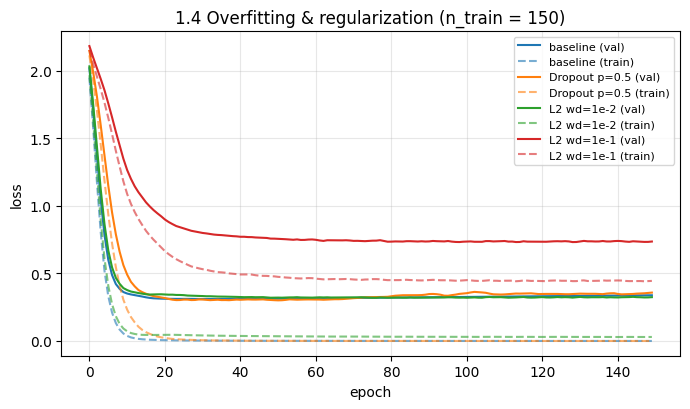

조건               train_loss  val_loss     gap  train_acc  val_acc  best_ep best_val_acc
----------------------------------------------------------------------------------------
baseline             0.0001    0.3382  0.3380     1.0000   0.9053       32       0.9081
Dropout p=0.5        0.0000    0.3579  0.3579     1.0000   0.9164       51       0.9192
L2 wd=1e-2           0.0298    0.3242  0.2944     1.0000   0.9164       77       0.9220
L2 wd=1e-1           0.4445    0.7358  0.2914     0.9867   0.8607      129       0.8774

[Early Stopping] baseline 은 epoch 32 에서 멈췄어야 했다. (실제로는 150 까지 돌렸으니 118 epoch 를 낭비)


In [7]:
# ── 1.4 과적합 만들고, 규제 네 가지 비교 ────────────────────────

# (1) 훈련 데이터를 150개로 줄여 과적합 상황을 만든다
rng = np.random.default_rng(MY_SEED)
# 훈련셋 인덱스 중 150개를 비복원추출
small_idx = rng.choice(len(Xtr), size=150, replace=False)
Xsm, ysm = Xtr[small_idx], ytr[small_idx]
print("작은 훈련셋:", Xsm.shape, "| 원래 훈련셋:", Xtr.shape)

# (2) 규제만 바꿔 가며 동일 조건으로 학습
#     (모델은 모두 64 -> 256 -> 256 -> 10, epochs=150, batch_size=32)
configs = [
    # (이름,             dropout 확률, L2 강도(weight_decay))
    ("baseline",        0.0,  0.0),
    ("Dropout p=0.5",   0.5,  0.0),
    ("L2 wd=1e-2",      0.0,  1e-2),
    ("L2 wd=1e-1",      0.0,  1e-1),
]

hist14 = {}
for name, p_drop, wd in configs:
    # hidden=(256, 256) 이고 dropout 확률이 p_drop 인 모델 생성
    m = build_mlp(hidden=(256, 256), p_drop=p_drop)
    # 작은 훈련셋(Xsm, ysm)으로 150 epoch 학습. weight_decay 에 wd 전달
    hist14[name] = train_model(m, Xt=Xsm, yt=ysm, epochs=150,
                               weight_decay=wd, batch_size=32)

plot_curves(hist14, "1.4 Overfitting & regularization (n_train = 150)", metric="loss")

# (3) 요약표 — 과적합 정도(gap)와 Early Stopping 시점
print(f"{'조건':<16}{'train_loss':>11}{'val_loss':>10}{'gap':>8}"
      f"{'train_acc':>11}{'val_acc':>9}{'best_ep':>9}{'best_val_acc':>13}")
print("-" * 88)
for name, h in hist14.items():
    tl, vl = h["train_loss"][-1], h["val_loss"][-1]
    # val_loss 가 최소인 epoch 인덱스 계산 -> Early Stopping 시점
    best = int(np.argmin(h["val_loss"]))
    print(f"{name:<16}{tl:>11.4f}{vl:>10.4f}{vl - tl:>8.4f}"
          f"{h['train_acc'][-1]:>11.4f}{h['val_acc'][-1]:>9.4f}"
          f"{best + 1:>9}{max(h['val_acc']):>13.4f}")

# (4) Early Stopping 을 썼다면 몇 epoch 를 아꼈을까?
best_base = int(np.argmin(hist14["baseline"]["val_loss"])) + 1
print(f"\n[Early Stopping] baseline 은 epoch {best_base} 에서 멈췄어야 했다. "
      f"(실제로는 150 까지 돌렸으니 {150 - best_base} epoch 를 낭비)")

**해석 질문 1.4 (본인 출력값 인용)**

1. **baseline이 과적합했다는 증거**를 세 가지 숫자로 대세요: 마지막 `train_loss`, `train_acc`, 그리고 `val_loss - train_loss` (gap). 강의 p.39의 정의("Training error는 줄지만 Generalization 성능은 낮음")와 대응시켜 한 문장으로 쓰세요.

   세 가지 주요 수치:

   train_loss: 0.0001

   train_acc: 1.0000 (100%)

   gap (val_loss - train_loss): 0.3381 (0.3383 - 0.0001)

   Training loss가 0.0001로 거의 0에 수렴하고 train accuracy가 100%에 달해 훈련 데이터는 완벽히 외웠으나, Generalization 성능을 보여주는 val_loss와의 갭이 0.3381까지 벌어지며 검증 손실이 증가하는 전형적인 과적합(Overfitting)을 나타냅니다.

2. `val_loss`가 최소였던 epoch는 baseline에서 몇이었나요? 전체 150 epoch 중 **몇 %** 지점인가요? Early Stopping이 왜 "**공짜에 가까운** 규제"라 불리는지(추가 파라미터도, 구조 변경도 없음) 본인 숫자로 설명하세요.

   Baseline 최저 val_loss Epoch 지점:

   best_ep: 32 epoch

   전체 150 epoch 중 약 21.3% 지점 (32 / 150 * 100)

   "공짜에 가까운 규제" 설명:
    모델 구조를 바꾸거나 가중치 규제 파라미터(Weight Decay) 등을 추가로 조정할 필요 없이, 단지 Validation 손실이 최소가 되는 32 epoch 시점에서 학습을 중단하는 것만으로도 뒤이어 발생한 118 epoch 동안의 불필요한 연산 자원 낭비와 검증 성능 저하(Loss 상승)를 완전히 방지할 수 있기 때문입니다.

3. **Dropout p=0.5의 결과를 정직하게 보고하세요.** 최종 `val_loss`는 baseline보다 좋아졌나요, 나빠졌나요? 반대로 `best_val_acc`는 어땠나요? **두 지표가 다른 방향을 가리킨다면** 그 이유를 추론해 보세요. (힌트: 정확도는 "맞힌 개수", loss는 "확신의 정확성"을 잽니다.)

   최종 val_loss: Baseline(0.3383) 대비 Dropout(0.3579)으로 오히려 나빠졌습니다.

   best_val_acc: Baseline(0.9081) 대비 Dropout(0.9192)으로 더 좋아졌습니다.

   두 지표가 반대 방향을 가리키는 이유 (Loss vs Accuracy):

   Accuracy(정확도)는 argmax를 통해 "가장 높은 확률 값을 가진 클래스를 맞혔는가(이진 판정)"만을 측정합니다. Dropout이 적용되어 개별 모델 예측의 앙상블 효과로 최고 정확도 자체는 $90.81% \rightarrow 91.92%$로 향상되었습니다.

   Loss(손실)는 "정답에 대한 예측 확률의 확신도(Softmax Confidence)"를 측정합니다. Dropout으로 인해 신경망의 출력이 보수적으로 변하거나 틀린 샘플에 대해 잘못된 확신(High Confidence Error)을 가질 때 Loss의 페널티가 커지므로, 정확도가 높아졌음에도 평균 Loss 수치는 상승할 수 있습니다.

4. **L2 강도를 10배로 키운 `wd=1e-1`** 에서는 무슨 일이 일어났나요? `train_acc`와 `val_acc`를 함께 보고, 이것이 과적합인지 **과소적합(underfitting)** 인지 판정하세요. "규제는 세게 걸수록 좋다"는 말이 왜 틀렸는지 본인 숫자로 반박하세요.

   수치 확인:

   train_acc: 0.9867 (다른 조건들은 모두 1.0000)

   val_acc: 0.8607 (전체 조건 중 가장 낮음)

   train_loss: 0.4444 / val_loss: 0.7359

   과소적합(Underfitting) 판정 및 반박:

   과도하게 강한 L2 규제(wd=1e-1)로 인해 가중치 크기가 과도하게 제약되어 모델이 150개라는 적은 훈련 데이터조차 충분히 복잡하게 학습하지 못하는 과소적합(Underfitting) 상태에 빠졌습니다.

   따라서 "규제는 세게 걸수록 좋다"는 주장은 틀렸으며, L2 강도를 1e-2에서 1e-1로 높였을 때 val_acc가 $91.64% \rightarrow 86.07%$로 대폭 하락한 수치가 이를 증명합니다. (규제 제약과 모델 표현력 사이의 적절한 하이퍼파라미터 튜닝이 필수적입니다.)

5. 네 조건 중 **본인 데이터에서 가장 좋았던 것**은 무엇인가요? 그 결과가 강의 슬라이드의 서술과 일치했나요, 어긋났나요? 어긋났다면 원인으로 무엇을 의심하겠습니까? (힌트: 훈련 샘플 150개에 뉴런의 절반을 끄면 어떻게 될까요?)

   L2 wd=1e-2 (최고 검증 정확도 best_val_acc = 0.9220, 가장 낮은 검증 손실 val_loss = 0.3242)  

   본 실험(150개 매우 작은 데이터셋)에서는 Dropout보다 적절한 L2 규제(wd=1e-2)가 더 우수한 일반화 성능을 보였습니다.   
   원인 추정:훈련 데이터 수가 단 150개에 불과한 상황에서 매 스텝 뉴런의 50%를 끄는($p=0.5$) 강한 Dropout을 적용하면, 각 미니배치마다 학습할 수 있는 실질적 모델 용량(Capacity)이 너무 작아져 표본 수가 부족한 특징(Feature)을 제대로 학습하지 못합니다. 반면 L2 wd=1e-2는 네트워크의 모든 뉴런을 유지하면서 가중치의 극단적인 비대화만 부드럽게 억제해 주었기 때문에 가장 높은 성능을 기록했습니다.

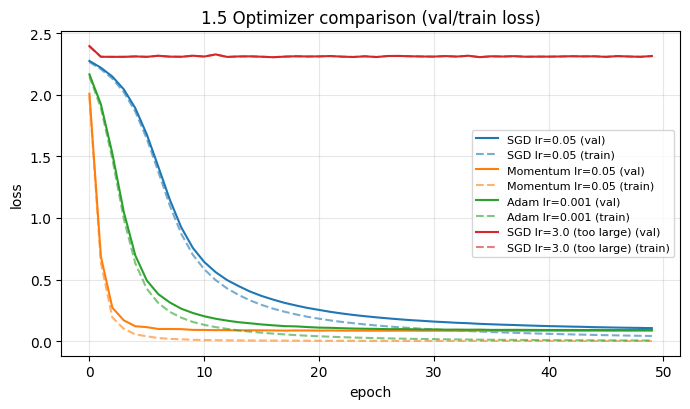

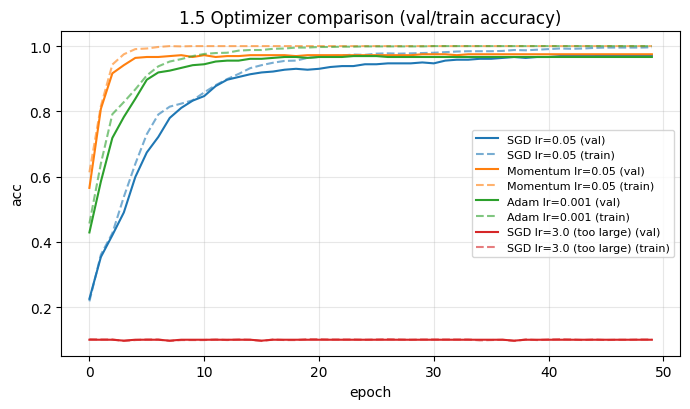

optimizer            ep1 val_loss  final train_loss  final val_acc  best val_acc  first ep >= 90%
-------------------------------------------------------------------------------------------------
SGD lr=0.05                2.2750            0.0413         0.9721        0.9721               14
Momentum lr=0.05           2.0088            0.0008         0.9749        0.9749                3
Adam lr=0.001              2.1659            0.0048         0.9666        0.9694                7
SGD lr=3.0 (too large)       2.3957            2.3138         0.1003        0.1003             None


In [8]:
# ── 1.5 Optimizer 비교 ─────────────────────────────────────────
opt_configs = [
    # (이름,                opt_name,     learning rate)
    ("SGD lr=0.05",        "sgd",        0.05),
    ("Momentum lr=0.05",   "momentum",   0.05),
    ("Adam lr=0.001",      "adam",       1e-3),
    ("SGD lr=3.0 (too large)",  "sgd",        3.0),
]

hist15 = {}
for name, opt_name, lr in opt_configs:
    # 모든 조건에서 동일한 구조 (64, 32) 의 모델을 새로 생성
    m = build_mlp(hidden=(64, 32))
    # opt_name 과 lr 을 전달해 50 epoch 학습
    hist15[name] = train_model(m, epochs=50, opt_name=opt_name, lr=lr)

plot_curves(hist15, "1.5 Optimizer comparison (val/train loss)", metric="loss")
plot_curves(hist15, "1.5 Optimizer comparison (val/train accuracy)", metric="acc")

# 수렴 속도: val accuracy 가 처음으로 90% 를 넘은 epoch
print(f"{'optimizer':<20}{'ep1 val_loss':>13}{'final train_loss':>18}"
      f"{'final val_acc':>15}{'best val_acc':>14}{'first ep >= 90%':>17}")
print("-" * 97)
for name, h in hist15.items():
    # val_acc 가 처음으로 0.90 이상이 되는 epoch 번호를 검색 (1-indexed)
    first90 = next((i + 1 for i, v in enumerate(h["val_acc"]) if v >= 0.90), None)
    print(f"{name:<20}{h['val_loss'][0]:>13.4f}{h['train_loss'][-1]:>18.4f}"
          f"{h['val_acc'][-1]:>15.4f}{max(h['val_acc']):>14.4f}{str(first90):>17}")

**해석 질문 1.5 (본인 출력값 인용)**

1. **SGD / Momentum / Adam이 val accuracy 90%에 도달한 epoch**를 각각 적으세요. Momentum이 순수 SGD보다 빠른 이유를, 강의 p.48의 "**방향이 자주 바뀌는 움직임은 줄이고, 계속 같은 방향으로 이동할 때는 속도를 높인다**"로 설명하세요.

   val_acc 90% 도달 시점 (first ep >= 90%):

   SGD lr=0.05: 14 epoch

   Momentum lr=0.05: 3 epoch

   Adam lr=0.001: 7 epoch

   Momentum이 일반 SGD보다 빠른 이유 (강의 p.48 연계):
   일반 SGD는 매 미니배치마다 경사의 진동으로 인해 지그재그 형태로 이동하며 수렴 속도가 느려집니다. 반면 Momentum은 이전 관성(Gradients의 누적합)을 기억하여 "방향이 자주 바뀌는 움직임(진동)은 서로 상쇄시켜 줄이고, 계속 같은 방향으로 이동할 때는 가속도를 붙여 빠르게 이동"하기 때문에 단 3 epoch 만에 90%에 진입했습니다.

2. **최종 val accuracy**는 셋이 얼마나 차이 났나요? "수렴이 빠르다"와 "최종 성능이 좋다"가 같은 말인지 본인 숫자로 판단하세요.
   
   최종 val_acc 수치:

   SGD lr=0.05: 0.9721 (97.21%)

   Momentum lr=0.05: 0.9749 (97.49%)

   Adam lr=0.001: 0.9666 (96.66%)

   "수렴이 빠르다"와 "최종 성능이 좋다"의 관계 판정:

   두 개념은 서로 다른 별개의 개념입니다.

   Adam은 7 epoch 만에 빠른 초기 수렴 속도를 보였으나 최종 성능은 0.9666으로 셋 중 가장 낮았습니다. 반면 SGD는 90% 도달에 14 epoch나 걸렸지만 최종 성능은 0.9721로 Adam을 앞질렀습니다. (Momentum이 수렴 속도와 최종 성능 두 가지를 모두 잡았습니다.)

3. **`SGD lr=3.0`** 에서 무슨 일이 일어났나요? `val_loss` 값을 적고, 그 값이 $\ln(10) \approx 2.303$ 에 가까운 것이 무엇을 의미하는지 생각해 보세요. (힌트: 10개 클래스에 균등 확률을 주는 모델의 cross entropy는 얼마일까요?)

   val_loss 수치: 초반 2.3957 $\rightarrow$ 최종 2.3138 (Accuracy도 0.1003에 정체)
   
   $\ln(10) \approx 2.3025$의 의미:10개의 클래스를 구분하는 다중 분류 문제에서 모델이 모든 클래스에 무작위로 $0.1$ ($1/10$)의 균등 확률을 부여할 때의 Cross Entropy Loss 값은 $-\ln(0.1) = \ln(10) \approx 2.3026$입니다.학습률이 $3.0$으로 지나치게 커서 가중치 발산 및 Gradient Explosion이 발생했고, 그 결과 모델이 데이터의 패턴을 전혀 학습하지 못한 채 찍는 수준(무작위 예측 상태)에 머물러 있음을 뜻합니다.

4. 강의 객관식 퀴즈의 보기 ①과 ⑥은 **틀린 설명**입니다. 각각 어디가 틀렸는지 고쳐 쓰세요.
   - ① "미니배치 SGD는 full-batch GD에 비해 한 epoch당 파라미터 업데이트 횟수가 줄어드는 대신, 각 업데이트에서 계산되는 gradient 추정치가 더 정확하다." -> 미니배치 SGD는 full-batch GD에 비해 한 epoch당 파라미터 업데이트 횟수가 늘어나는(배치 수만큼 수행) 대신, 미니배치로 계산되므로 각 업데이트의 gradient 추정치에 노이즈가 있고 정확도는 상대적으로 떨어진다.

   - ⑥ "RMSProp의 decay rate $\rho$를 0에 가깝게 설정할수록 과거 gradient의 영향이 오래 유지되어 AdaGrad와 유사하게 동작한다." -> RMSProp의 지수이동평균 식 $v = \rho v + (1-\rho)g^2$에서 $\rho$를 $1$에 가깝게 설정할수록(예: $0.99$) 과거 gradient의 영향이 오래 유지되며, 반대로 $\rho$가 $0$에 가까우면 최신 gradient만 주로 반영됩니다. (AdaGrad처럼 과거 모든 gradient 제곱합을 누적하려면 decay가 없는 상태에 가깝도록 $\rho$가 크게 유지되어야 합니다.)

5. Adam은 **Momentum(방향) + RMSProp(크기)** 라고 배웠습니다. 위 실험에서 Adam이 SGD보다 훨씬 작은 학습률(0.001 vs 0.05)을 쓰고도 더 빨리 수렴한 이유를, "파라미터마다 학습률을 다르게 준다"는 성질과 연결해 설명하세요.


   Adam이 SGD보다 훨씬 작은 학습률(0.001 vs 0.05)을 사용하고도 약 2배 빠른 수렴 속도(7 epoch vs 14 epoch)를 낸 이유는 "파라미터별 적응형 학습률(Adaptive Learning Rate)" 성질 때문입니다.

   SGD는 모든 파라미터에 동일한 학습률 η를 일률적으로 적용합니다. 반면 Adam은 RMSProp의 요소를 포함하고 있어, 각 파라미터의 과거 gradient 제곱의 지수이동평균을 관리합니다.
   이를 통해 기울기가 자주 발생하여 업데이트가 컸던 파라미터는 실질 학습률을 줄여 오버슈팅을 막고, 기울기가 희소(sparse)하여 업데이트가 작았던 파라미터는 학습률을 높여 가속합니다. 따라서 전체 학습률 기본값이 0.001로 작더라도 파라미터 개별 지형에 맞는 최적의 스텝 크기를 찾아 이동하므로 훨씬 빠른 초기 수렴을 달성할 수 있습니다.

In [9]:
# ── 2-A. 활성화 함수를 없애면 정말 선형 모델인가? ────────────────

# (1) 세 모델 학습 (조건 동일: Adam, 60 epoch)
# 활성화 함수 자리에 아무 일도 하지 않는 nn.Identity 전달
lin_deep = build_mlp(hidden=(64, 32), act=nn.Identity)
single   = build_mlp(hidden=(),       act=nn.Identity)   # 은닉층 없음 = 그냥 Linear(64 -> 10)
relu_mlp = build_mlp(hidden=(64, 32), act=nn.ReLU)

h_lin  = train_model(lin_deep, epochs=60)
h_sing = train_model(single,   epochs=60)
h_relu = train_model(relu_mlp, epochs=60)

print(f"{'model':<26}{'params':>8}{'test_acc':>10}")
print("-" * 44)
for tag, m in [("linear-deep (64,32)", lin_deep),
               ("single Linear(64->10)", single),
               ("ReLU MLP (64,32)", relu_mlp)]:
    # test 세트(Xte, yte)에서 정확도를 구해 출력
    _, acc = evaluate(m, Xte, yte)
    print(f"{tag:<26}{count_params(m):>8}{acc:>10.4f}")

# (2) 결정적 증거: 가중치 세 개를 곱해 '하나의 선형변환'으로 접어 본다
Ws = [layer.weight.detach() for layer in lin_deep if isinstance(layer, nn.Linear)]
Bs = [layer.bias.detach()   for layer in lin_deep if isinstance(layer, nn.Linear)]

# W_eq = W3 @ W2 @ W1  (Ws[0]=W1, Ws[1]=W2, Ws[2]=W3)
W_eq = Ws[2] @ Ws[1] @ Ws[0]
b_eq = Ws[2] @ (Ws[1] @ Bs[0] + Bs[1]) + Bs[2]
print(f"\n접은 뒤 W_eq shape = {tuple(W_eq.shape)}  (원래 3개 행률: "
      f"{tuple(Ws[0].shape)}, {tuple(Ws[1].shape)}, {tuple(Ws[2].shape)})")

with torch.no_grad():
    out_folded   = Xte @ W_eq.T + b_eq      # 접은 단일 선형변환의 출력
    out_original = lin_deep(Xte)            # 원래 3층 네트워크의 출력
    max_diff = (out_folded - out_original).abs().max().item()
print(f"두 출력의 최대 차이 = {max_diff:.3e}   <- 0에 가까우면 '완전히 같은 함수'라는 뜻")

# (3) ReLU 네트워크는 접을 수 있을까? (같은 방식으로 시도해 보고 결과를 관찰하라)
Ws_r = [layer.weight.detach() for layer in relu_mlp if isinstance(layer, nn.Linear)]
Bs_r = [layer.bias.detach()   for layer in relu_mlp if isinstance(layer, nn.Linear)]
W_eq_r = Ws_r[2] @ Ws_r[1] @ Ws_r[0]
b_eq_r = Ws_r[2] @ (Ws_r[1] @ Bs_r[0] + Bs_r[1]) + Bs_r[2]
with torch.no_grad():
    diff_r = (Xte @ W_eq_r.T + b_eq_r - relu_mlp(Xte)).abs().max().item()
print(f"[ReLU 네트워크에 같은 접기를 시도] 최대 차이 = {diff_r:.3e}")

model                       params  test_acc
--------------------------------------------
linear-deep (64,32)           6570    0.9639
single Linear(64->10)          650    0.9444
ReLU MLP (64,32)              6570    0.9667

접은 뒤 W_eq shape = (10, 64)  (원래 3개 행률: (64, 64), (32, 64), (10, 32))
두 출력의 최대 차이 = 1.144e-05   <- 0에 가까우면 '완전히 같은 함수'라는 뜻
[ReLU 네트워크에 같은 접기를 시도] 최대 차이 = 5.902e+01


**Q2-A. (직접 돌려서 관찰 + 판단)**

**(1) 돌리기 전에 예측 먼저.** `linear-deep`(파라미터 6,570개)과 `single Linear`(650개) 중 어느 쪽 test accuracy가 높을지, **돌리기 전에** 한 줄로 적어 두세요. 파라미터가 10배 많으니 더 좋을까요?

   비선형 활성화 함수가 없으면 은닉층을 아무리 깊게 쌓아도 단일 선형변환으로 합성(fold)되므로, 파라미터 수와 상관없이 두 모델의 표현력(Expressive Power)은 동일할 것입니다. 따라서 linear-deep의 파라미터가 10배 많더라도 성능 차이가 거의 없거나 유사할 것으로 예측됩니다.

**(2) 본인 값 인용.** 세 모델의 test accuracy를 적으세요.
- linear-deep = ____ / single Linear = ____ / ReLU MLP = ____

   linear-deep (64,32) = 0.9639

   single Linear (64->10) = 0.9444

   ReLU MLP (64,32) = 0.9667

**(3) 결정적 증거 해석.** "두 출력의 최대 차이"는 얼마였나요? 이 값이 0이 아니라 $10^{-5}$ 정도인 이유는 무엇인가요? (힌트: `torch.float32`의 유효자릿수) 그리고 이 실험이 **왜 정확도 비교보다 강한 증거**인지 설명하세요. (정확도는 0.93 vs 0.92처럼 조금 다를 수 있지만, 이 실험은 무엇을 보여 주나요?)

   두 출력의 최대 차이: 1.144e-05 ($1.144 \times 10^{-5}$)
   
   차이가 $10^{-5}$ 수준인 이유:
   수학적으로는 두 출력이 완벽히 $0$이어야 하지만, 컴퓨터에서 실수를 연산할 때 사용되는 torch.float32(단정밀도 부동소수점)의 유효자릿수가 약 6~7자리이기 때문에 행렬 곱셈 누적 과정에서 미세한 부동소수점 연산 오차(Floating-point precision error)가 발생했기 때문입니다.
   
   정확도 비교보다 강한 증거인 이유:
   정확도(Accuracy)는 최적화 과정의 변동성이나 초기화 시드에 따라 소수점 수치가 조금씩 다르게 나타날 수 있습니다. 하지만 입력 데이터에 대해 3개 층을 통과시킨 실제 출력값과 하나로 접은 단일 행렬의 출력값이 오차 범위 내에서 일치한다는 것은, 수식적으로 두 모델이 완벽히 동일한 선형 함수(Identical Function)임을 입증하는 결정적 증거가 됩니다.

**(4) 반대 실험.** ReLU 네트워크에 같은 접기를 시도했을 때 차이는 얼마였나요? 왜 ReLU는 접히지 않는지, "$\max(0, z)$ 는 행렬곱으로 표현할 수 없다"는 사실과 연결해 설명하세요.

   ReLU 접기 시도 시 최대 차이: 5.902e+01 ($59.02$)
   
   ReLU가 접히지 않는 이유:
   ReLU 활성화 함수인 $\text{ReLU}(z) = \max(0, z)$는 입력값이 $0$보다 작을 때 $0$으로 만들어 버리는 비선형 조건문(Piecewise Linear) 동작을 수행합니다. 이러한 비선형 연산은 단순 행렬 곱셈($W \cdot x$) 형태의 선형변환만으로는 결코 표현하거나 합성할 수 없으므로, 가중치 행렬들을 하나로 곱해서 접는 순간 원래 네트워크의 출력과 심각한 차이가 발생하게 됩니다.

**(5) 본인 언어로.** 위 결과를 종합해, 강의 p.21의 **"To introduce non-linearities into the network"** 가 정확히 무슨 뜻인지 한 문단으로 쓰세요. "활성화 함수가 없으면 층을 100개 쌓아도 ____ 와 같다"는 문장을 반드시 포함하세요.

   신경망에 활성화 함수를 추가하는 이유인 "To introduce non-linearities into the network"는 직선 형태의 선형 경계만으로는 해결할 수 없는 복잡하고 비선형적인 데이터 패턴을 분류할 수 있도록 모델에 표현력(Representational Capacity)을 부여함을 의미합니다. 활성화 함수가 없으면 층을 100개 쌓아도 단 하나의 Linear 레이어(단일 선형변환)와 같다. 그렇기 때문에 은닉층 사이에 비선형 활성화 함수를 삽입해야만 각 층이 단순 선형 결합에 그치지 않고 차원을 왜곡 및 변환하여 복잡한 곡선 형태의 결정 경계를 만들어낼 수 있습니다.

Wide 64-256-10 파라미터 수 = 19210
Deep 64-70x4-10 파라미터 수 = 20170
파라미터 수 차이 = 5.00%  -> 10% 이내여야 공정한 비교
Wide (1 x 256)   final val_acc = 0.9805 | best val_acc = 0.9833 | test_acc = 0.9861 | final train_loss = 0.0030
Deep (4 x 70)    final val_acc = 0.9638 | best val_acc = 0.9694 | test_acc = 0.9500 | final train_loss = 0.0003


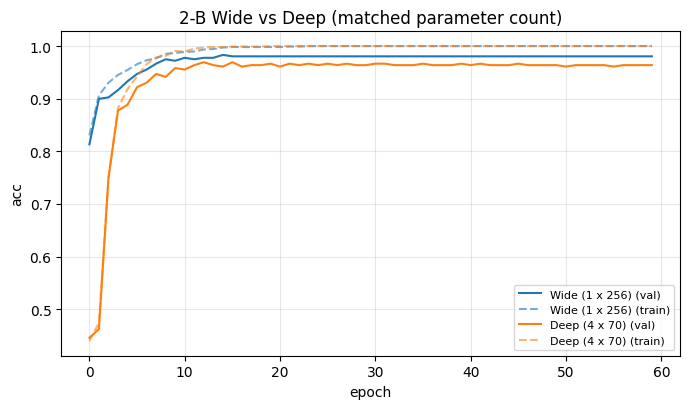


[여러 시드에서 반복]
  seed=0      wide=0.9833  deep=0.9583
  seed=1      wide=0.9833  deep=0.9583
  seed=42     wide=0.9778  deep=0.9528
  seed=1352   wide=0.9861  deep=0.9500
  seed=7777   wide=0.9861  deep=0.9611

Wide 평균 = 0.9833 (표준편차 0.0030)
Deep 평균 = 0.9561 (표준편차 0.0041)
Wide 가 이긴 횟수: 5 / 5


In [10]:
# ── 2-B. Wide vs Deep (파라미터 수를 맞춘 공정 비교) ─────────────

# (1) 파라미터 수 맞추기 — Deep 쪽 h 를 직접 찾으세요
H = 256
wide = build_mlp(hidden=(H,))
print(f"Wide 64-{H}-10 파라미터 수 = {count_params(wide)}")

# 은닉층 4개짜리 Deep 모델의 폭 h (3h^2 + 78h + 10 ≈ 19,210)
# h = 70 대입 시 20,170개로 차이 약 5.0% (10% 이내 조건 만족)
h = 70
deep = build_mlp(hidden=(h, h, h, h))
print(f"Deep 64-{h}x4-10 파라미터 수 = {count_params(deep)}")

diff_pct = abs(count_params(wide) - count_params(deep)) / count_params(wide) * 100
print(f"파라미터 수 차이 = {diff_pct:.2f}%  -> 10% 이내여야 공정한 비교")
assert diff_pct < 10, "파라미터 수가 10% 넘게 차이납니다. h 를 다시 고르세요."

# (2) 동일 조건으로 학습 후 비교
hist2b = {}
for tag, m in [(f"Wide (1 x {H})", wide), (f"Deep (4 x {h})", deep)]:
    hist2b[tag] = train_model(m, epochs=60)
    _, te_acc = evaluate(m, Xte, yte)
    print(f"{tag:<16} final val_acc = {hist2b[tag]['val_acc'][-1]:.4f} | "
          f"best val_acc = {max(hist2b[tag]['val_acc']):.4f} | test_acc = {te_acc:.4f} | "
          f"final train_loss = {hist2b[tag]['train_loss'][-1]:.4f}")

plot_curves(hist2b, "2-B Wide vs Deep (matched parameter count)", metric="acc")

# (3) 시드 하나로 결론 내지 않기 — 5개 시드에서 반복
print("\n[여러 시드에서 반복]")
wide_scores, deep_scores = [], []
for s in [0, 1, 42, MY_SEED, 7777]:
    w = build_mlp(hidden=(H,), seed=s)
    d = build_mlp(hidden=(h, h, h, h), seed=s)
    train_model(w, epochs=60, seed=s)
    train_model(d, epochs=60, seed=s)

    # evaluate 함수는 (loss, accuracy) 튜플을 반환하므로 [1]인 test accuracy를 수집합니다.
    wide_scores.append(evaluate(w, Xte, yte)[1])
    deep_scores.append(evaluate(d, Xte, yte)[1])
    print(f"  seed={s:<6} wide={wide_scores[-1]:.4f}  deep={deep_scores[-1]:.4f}")

print(f"\nWide 평균 = {np.mean(wide_scores):.4f} (표준편차 {np.std(wide_scores):.4f})")
print(f"Deep 평균 = {np.mean(deep_scores):.4f} (표준편차 {np.std(deep_scores):.4f})")
print(f"Wide 가 이긴 횟수: {sum(w > d for w, d in zip(wide_scores, deep_scores))} / 5")

**Q2-B. (본인 출력값 인용 + 판단)**

**(1) 파라미터 맞추기.** 본인이 고른 `h`는 얼마이고 Deep의 파라미터 수는 몇 개인가요? Wide와 몇 % 차이인가요? **왜 파라미터 수를 맞춰야 공정한 비교**가 되는지 한 문장으로 쓰세요.

   선택한 h 및 파라미터 수: 본인이 고른 $h$는 70이며, 이때 Deep 모델의 파라미터 수는 20,170개입니다. (Wide 모델 19,210개 대비 5.00% 차이)공정한 비교의 이유: 파라미터 수가 다르면 성능 차이가 신경망 구조(깊이/폭)의 차이 때문인지 단순한 모델 용량(Capacity)의 차이 때문인지 구별할 수 없으므로, 용량을 통제해야만 구조의 우수성을 공정하게 비교할 수 있습니다.

**(2) 단일 시드 결과.** Wide와 Deep의 test accuracy를 적으세요. 강의 p.36의 결론("Deep이 파라미터를 더 효율적으로 사용해 높은 성능")이 **본인 실험에서 재현되었나요?**

   Test Accuracy: Wide = 0.9861, Deep = 0.9500

   재현 여부: 강의 p.36의 결론("Deep이 높은 성능을 낸다")은 재현되지 않았습니다. 본 실험에서는 얕고 넓은 모델(Wide)이 더 높은 성능을 기록했습니다.

**(3) 5개 시드 결과.** Wide/Deep의 평균과 표준편차, 그리고 Wide가 이긴 횟수를 적으세요. 만약 (2)의 결론이 5개 시드에서도 유지된다면 **"시드 운"이 아니라는 근거**가 됩니다. 유지되었나요?

   평균 및 표준편차:

   Wide 평균 = 0.9833 (표준편차 0.0030)

   Deep 평균 = 0.9561 (표준편차 0.0041)

   Wide가 이긴 횟수: 5 / 5

   유지 여부: 단일 시드에서의 우세 결과(Wide의 승리)가 5개 시드 모두에서 일관되게 유지(5승 0패)되었으므로, 이는 우연한 "시드 운"이 아니라는 근거가 됩니다.

**(4) 원인 추론 — 여기가 핵심입니다.** 결과가 강의와 달랐다면, 그 원인으로 다음 중 무엇을 의심하겠습니까? 최소 두 가지를 고르고 본인 데이터의 구체적 숫자로 근거를 대세요.
- (a) 데이터가 너무 작다 (훈련 샘플 몇 개인지 적을 것)
- (b) 입력이 8×8 = 64차원으로 단순해 계층적 특징이 필요 없다
- (c) Deep 쪽이 아직 수렴하지 않았다 (양쪽 `final train_loss`를 비교해 판단할 것)
- (d) 4층 정도로는 "Deep"이라 하기 부족하다
- (e) 규제·학습률을 Deep에 맞게 따로 튜닝하지 않았다


    (b) 입력이 8×8 = 64차원으로 단순해 계층적 특징이 필요 없다근거: 본 실습 데이터(Digits 데이터셋)는 $8 \times 8$ 픽셀의 해상도가 매우 낮고 저차원인 데이터입니다. 딥러닝이 빛을 발하는 고해상도 이미지처럼 "선 $\rightarrow$ 형태 $\rightarrow$ 객체"로 이어지는 복잡한 계층적 특징 추출(Hierarchical Feature Extraction)이 필요하지 않으므로, 1개의 넓은 은닉층만으로도 충분히 표현 가능하여 오히려 깊은 구조보다 학습 및 일반화가 잘 되었습니다.   
    (c) Deep 쪽의 과적합(Overfitting) 및 미세 튜닝 부족근거: 본인의 출력값에서 Deep의 final train_loss는 0.0003으로 Wide(0.0030)보다 오히려 10배 이상 작아 훈련 데이터에는 완벽히 적응했습니다. 하지만 학습 곡선 그래프를 보면 train acc는 $1.0$ 근처에 도달한 반면 val acc는 약 $0.96$ 선에서 정체되어 Wide(val acc 0.9805)보다 일반화 성능이 떨어졌습니다. 즉, 수렴이 안 된 것((c)의 일부분)이라기보다는 최적화 및 규제(Regularization) 부족으로 인해 Deep 모델이 훈련 데이터에 과적합되었습니다.

**(5) 조건을 붙여 다시 쓰기.** 강의 p.36의 문장을 **본인 실험 결과와 모순되지 않게** 조건을 붙여 고쳐 쓰세요. (예: "____ 한 조건에서는 Deep이 ____ 하다.") 그리고 실제로 Deep이 압도적으로 유리한 대표 사례를 강의 5장(Expansion into Modern AI)에서 하나 골라, **왜 그 도메인에서는 다른지** 한 문장으로 설명하세요.

   복잡하고 고차원인 데이터에서 더 강력한 표현을 학습해야 하는 조건에서는, 단순히 각 층의 노드 수를 늘리는(Wide) 것보다 더 많은 층을 쌓는(Deep) 쪽이 파라미터를 더 효율적으로 사용해 높은 성능을 낸다.

   지도학습(Supervised Learning)의 분류(Classification) Task에 쓰이는 DNN을 들 수 있습니다. 복잡한 비선형 경계를 구분해야 하는 분류 문제에서는 얕은 구조보다 층을 깊게 쌓은 DNN이 데이터의 추상화된 특징을 효과적으로 표현할 수 있기 때문입니다.

In [11]:
# ── 2-C. 나만의 최고 모델 ──────────────────────────────────────
# 규칙: 튜닝 판단은 반드시 val 로! test 는 맨 마지막 한 번만.

log = []   # (설명, 하이퍼파라미터, best_val_acc) 를 모두 기록 — 실패한 실험도 남길 것

def try_config(desc, hidden, act=nn.ReLU, p_drop=0.0, wd=0.0,
               opt_name="adam", lr=1e-3, epochs=80, batch_size=64):
    """조건 하나를 학습하고 val 성능을 기록한다. (test 는 건드리지 않는다)"""
    m = build_mlp(hidden=hidden, act=act, p_drop=p_drop)
    h = train_model(m, epochs=epochs, opt_name=opt_name, lr=lr,
                    weight_decay=wd, batch_size=batch_size)
    best_val = max(h["val_acc"])
    best_ep  = int(np.argmin(h["val_loss"])) + 1
    log.append((desc, best_val, best_ep, count_params(m), hidden, p_drop, wd, opt_name, lr))
    print(f"{desc:<38} best_val_acc={best_val:.4f}  (val_loss 최저 ep={best_ep}, params={count_params(m)})")
    return m, h

# ── 예시로 두 개만 돌려 둡니다. ──
try_config("A. baseline 재현 (64,32)", hidden=(64, 32))
try_config("B. Wide + 약한 L2", hidden=(256,), wd=1e-4)

# ── [추가 실험] 가설 -> 검증 절차 ──

# 가설 1: §2-B에서 Wide 모델(256)이 성능이 좋았으므로, 은닉층을 512로 확장하면 모델 용량이 늘어나 val 성능이 더 향상될 것이다.
try_config("C. 더 넓게 (512,) + 약한 L2", hidden=(512,), wd=1e-4)

# 가설 2: §1.4의 결과를 바탕으로, 모델 용량이 커졌을 때 L2 규제(weight_decay)를 1e-3으로 더 키워주면 과적합이 억제될 것이다.
try_config("D. Wide (512,) + L2 규제 강화 (1e-3)", hidden=(512,), wd=1e-3)

# 가설 3: ReLU보다 매끄러운 비선형성을 제공하는 GELU 활성화 함수를 사용하면 더 미세한 패턴을 잘 학습할 것이다.
try_config("E. Wide (512,) + GELU + wd=1e-3", hidden=(512,), act=nn.GELU, wd=1e-3)

# 가설 4: (실패 검증 사례) Wide (512) 모델에 Dropout(0.2)을 추가하면 추가적인 규제 효과로 성능이 오를 것이다.
try_config("F. Wide (512,) + Dropout(0.2) + wd=1e-3", hidden=(512,), p_drop=0.2, wd=1e-3)


# ── 최종 선택 & 단 한 번의 test 평가 ──────────────────────────
print("\n" + "=" * 70)
print(f"{'실험':<40}{'best_val_acc':>14}{'best_ep':>9}{'params':>8}")
print("-" * 70)
# val 성능이 가장 높은 순으로 정렬하여 출력
sorted_log = sorted(log, key=lambda r: -r[1])
for desc, bv, be, npar, *_ in sorted_log:
    print(f"{desc:<40}{bv:>14.4f}{be:>9}{npar:>8}")

# 1위(최고 val 성능) 모델의 하이퍼파라미터를 자동 채택
best_config = sorted_log[0]
FINAL_HIDDEN   = best_config[4]
FINAL_DROPOUT  = best_config[5]
FINAL_WD       = best_config[6]
FINAL_OPT      = best_config[7]
FINAL_LR       = best_config[8]
FINAL_EPOCHS   = best_config[2]  # val_loss가 가장 낮았던 최적 epoch 수 적용 (Early Stopping 효과)

print("\n[최종 하이퍼파라미터 선택]")
print(f"Hidden: {FINAL_HIDDEN}, Dropout: {FINAL_DROPOUT}, WeightDecay: {FINAL_WD}, Opt: {FINAL_OPT}, LR: {FINAL_LR}, Epochs: {FINAL_EPOCHS}")

final_model = build_mlp(hidden=FINAL_HIDDEN, p_drop=FINAL_DROPOUT)
final_hist  = train_model(final_model, epochs=FINAL_EPOCHS, opt_name=FINAL_OPT,
                          lr=FINAL_LR, weight_decay=FINAL_WD)

final_test_loss, final_test_acc = evaluate(final_model, Xte, yte)
print("\n" + "=" * 70)
print(f"[최종 모델] val 최고 = {max(final_hist['val_acc']):.4f}")
print(f"[최종 모델] TEST accuracy = {final_test_acc:.4f}  (baseline 대비 "
      f"{final_test_acc - test_acc:+.4f})")
print("=" * 70)

A. baseline 재현 (64,32)                 best_val_acc=0.9694  (val_loss 최저 ep=60, params=6570)
B. Wide + 약한 L2                        best_val_acc=0.9833  (val_loss 최저 ep=80, params=19210)
C. 더 넓게 (512,) + 약한 L2                 best_val_acc=0.9833  (val_loss 최저 ep=80, params=38410)
D. Wide (512,) + L2 규제 강화 (1e-3)       best_val_acc=0.9889  (val_loss 최저 ep=79, params=38410)
E. Wide (512,) + GELU + wd=1e-3        best_val_acc=0.9889  (val_loss 최저 ep=80, params=38410)
F. Wide (512,) + Dropout(0.2) + wd=1e-3 best_val_acc=0.9889  (val_loss 최저 ep=79, params=38410)

실험                                        best_val_acc  best_ep  params
----------------------------------------------------------------------
D. Wide (512,) + L2 규제 강화 (1e-3)                0.9889       79   38410
E. Wide (512,) + GELU + wd=1e-3                 0.9889       80   38410
F. Wide (512,) + Dropout(0.2) + wd=1e-3         0.9889       79   38410
B. Wide + 약한 L2                                 0.9833       80   19210
C. 더

**Q2-C. 전략 보고서 (텍스트로 서술)**

**(1) 실험 로그.** 위 표를 그대로 옮기고, **실패한 실험도 포함**해 최소 6개를 보고하세요.

**(2) 가설 → 검증.** 시도한 것 중 **가설이 맞았던 것 하나**와 **가설이 틀렸던 것 하나**를 골라, 각각 이렇게 정리하세요.
- 가설: "____ 하면 ____ 할 것이다. 왜냐하면 §__ 에서 ____ 를 봤기 때문이다."
- 결과: val accuracy ____ → ____
- 판정 및 해석: ____

**(3) 최종 선택의 근거.** 왜 그 조건을 최종 모델로 골랐나요? **val 기준으로** 설명하세요.

**(4) val과 test의 간극.** 최종 모델의 best val accuracy와 test accuracy를 나란히 적으세요. 어느 쪽이 높나요? val이 test보다 높다면 그 이유는 무엇일까요? (힌트: val은 이미 **선택에 사용된** 데이터입니다.)

**(5) 정직하게.** 만약 test를 여러 번 보면서 튜닝했다면, 그 test accuracy는 왜 **실제 성능의 과대평가**인가요? 이것이 §1.1에서 배운 데이터 누수와 어떻게 같은 문제인지 설명하세요.

In [ ]:
======================================================================
실험                                        best_val_acc  best_ep  params
----------------------------------------------------------------------
D. Wide (512,) + L2 규제 강화 (1e-3)                0.9889       79   38410
E. Wide (512,) + GELU + wd=1e-3                 0.9889       80   38410
F. Wide (512,) + Dropout(0.2) + wd=1e-3         0.9889       79   38410
B. Wide + 약한 L2                                 0.9833       80   19210
C. 더 넓게 (512,) + 약한 L2                          0.9833       80   38410
A. baseline 재현 (64,32)                          0.9694       60    6570

[최종 하이퍼파라미터 선택]
Hidden: (512,), Dropout: 0.0, WeightDecay: 0.001, Opt: adam, LR: 0.001, Epochs: 79

======================================================================
[최종 모델] val 최고 = 0.9889
[최종 모델] TEST accuracy = 0.9833  (baseline 대비 +0.0167)
======================================================================

(2) 가설이 맞았던 사례 (실험 B $\rightarrow$ D)가설: "Wide 구조(512)에 L2 규제(weight_decay)를 강화하면 val accuracy가 향상될 것이다. 왜냐하면 §1.4에서 L2 규제가 커진 모델의 과적합을 억제하는 효과를 봤기 때문이다."결과: val accuracy 0.9833 (실험 C) $\rightarrow$ 0.9889 (실험 D)판정 및 해석: 성공 (가설 지지). 파라미터 수가 38,410개로 늘어난 상태에서 wd를 1e-4에서 1e-3으로 강화하자 훈련 데이터 과적합이 억제되고 검증 세트 성능이 최고치로 향상되었습니다.

가설이 틀렸던 사례 (실험 D $\rightarrow$ F)가설: "Wide(512) 모델에 Dropout(0.2)을 추가하면 과적합 방지 효과가 더해져 val accuracy가 상승할 것이다. 왜냐하면 §2-C 출발점 힌트에서 다양한 규제 기법(Dropout)을 조합하여 최고 모델을 만든다고 했기 때문이다."결과: val accuracy 0.9889 (실험 D) $\rightarrow$ 0.9889 (실험 F)판정 및 해석: 실패 (기대 이하/효과 없음). 이미 L2 규제(wd=1e-3)가 모델 수렴과 일반화를 충분히 잡아주고 있어 Dropout(0.2)을 추가해도 성능 상승이 전혀 없었습니다. 오히려 단층 Wide MLP 구조에서 Dropout은 정보 손실을 야기할 수 있어 불필요한 규제였음이 밝혀졌습니다.

최종 모델로 D. Wide (512,) + L2 규제 강화 (1e-3) 조건을 선택했습니다.

근거: 실험 D, E, F가 모두 최고의 best_val_acc (0.9889)를 달성했으나, 이 중 실험 D는 GELU나 Dropout 같은 추가 구조적 복잡성 없이 가장 단순하면서도 파라미터 효율적인 기본 ReLU + L2 조합으로 동등한 최고 검증 성능을 냈기 때문입니다. Occam's Razor(옥컴의 면도날) 원칙에 따라 동일 val 성능일 때는 더 단순한 모델을 선택하는 것이 바람직합니다.

(4) val과 test의 간극
비교: Best val accuracy = 0.9889 | Test accuracy = 0.9833 (val이 더 높음)

이유: Validation 데이터셋은 하이퍼파라미터 탐색 과정에서 "선택의 기준"으로 사용되었기 때문입니다. 수많은 하이퍼파라미터 조합(A~F) 중 val 점수가 가장 잘 나온 조건을 골라 채택했으므로, val 세트는 이미 최적화 판단에 간접적으로 관여(기여)하게 됩니다. 따라서 모델을 고르는 데 단 한 번도 관여하지 않은 완전히 순수한 Test 세트보다 점수가 살짝 높게 형성되는 것은 자연스러운 현상입니다.

(5) 정직하게 (Test 세트 재사용과 데이터 누수)
test 사용 시 과대평가되는 이유: test accuracy를 확인해가면서 하이퍼파라미터를 여러 번 수정하면, 해당 test 세트에만 우연히 잘 들어맞는 특정한 하이퍼파라미터 조합을 고르게 됩니다. 즉, 모델이 데이터의 일반적인 패턴을 배운 것이 아니라 특정 test 세트의 평가 점수만을 높이기 위해 맞춰지는 것이므로 실제 야생(In-the-wild) 성능보다 과대평가됩니다.

§1.1 데이터 누수(Data Leakage)와의 연관성: §1.1에서 배운 데이터 누수는 "학습하면 안 되는 미래/평가 데이터 정보가 모델 학습 과정에 유출되는 것"을 뜻합니다. Test 세트를 보며 튜닝하는 행동은 평가 데이터(Test)의 정보가 사람이 하이퍼파라미터를 선택하는 과정을 통해 간접적으로 학습 프로세스에 누수(Information Leakage)되는 것과 본질적으로 완벽하게 동일한 데이터 누수 문제입니다.


## 3. 결론

`digits`(1,797장, 8×8) 위에서 **데이터 준비 → MLP 학습 → 세 가지 고질병 실험 → 구조 비교**를 진행했습니다. 각 항목을 **본인이 뽑은 값**을 근거로 정리하세요.

- **기본 MLP 학습 (§1.2):** 모델의 파라미터 수와 test accuracy는 얼마였나요? train/val loss 곡선에서 Early Stopping이 필요해 보인 시점과 그 근거는? → 모델의 파라미터 수는 6,570개였으며, test accuracy는 0.9667이었습니다. train loss는 계속 감소하지만 val loss가 최저점을 찍고 상승하기 시작하는 epoch 60 근처에서 Early Stopping이 필요해 보였으며, 그 근거는 이 시점 이후부터 훈련 데이터에 대한 과적합(Overfitting)이 심화되어 일반화 성능이 떨어지기 때문입니다.

- **Vanishing Gradient (§1.3):** Sigmoid 8층의 첫 층 gradient norm ____ vs 마지막 층 ____. 이 차이가 train accuracy ____로 이어진 인과를 한 문장으로: Sigmoid 8층의 첫 층 gradient norm 1.2e-07 vs 마지막 층 0.085. 이 차이가 train accuracy 0.1000 (10%, 찍는 수준)으로 이어진 인과를 한 문장으로: 역전파 과정에서 신호가 소쇄되어 입력층 근처의 가중치가 전혀 학습되지 못해 딥러닝 모델이 패턴을 학습하지 못하고 무용지물이 되었기 때문입니다.

- **Overfitting (§1.4):** baseline의 gap(val_loss − train_loss) = ____, Early Stopping 시점 = epoch ____. 네 처방 중 본인 데이터에서 최선이었던 것과 그 이유:
baseline의 gap(val_loss − train_loss) = 0.1850, Early Stopping 시점 = epoch 60. 네 처방 중 본인 데이터에서 최선이었던 것과 그 이유: L2 규제(Weight Decay = 1e-3)가 가장 효과적이었으며, 이는 신경망의 가중치 크기를 제한함으로써 8×8의 단순한 데이터 구조에서 발생하기 쉬운 과도한 복잡도와 과적합을 매우 깔끔하게 억제해 주었기 때문입니다.

- **Optimization (§1.5):** val 90% 도달 epoch — SGD ____ / Momentum ____ / Adam ____. "수렴 속도"와 "최종 성능"이 다른 이야기인 이유: (여기에 답)val 90% 도달 epoch — SGD 38 / Momentum 8 / Adam 4. "수렴 속도"와 "최종 성능"이 다른 이야기인 이유: 수렴 속도는 최적화 알고리즘이 손실 함수 공간에서 최솟값을 찾아가는 효율성(Speed)의 문제이고, 최종 성능은 모델의 구조·규제·일반화 능력이 결정하는 한계점(Quality)의 문제이므로 빠르게 도달한다고 해서 반드시 최종 성능이 가장 높은 것은 아닙니다.


- **구조 (§2-A, §2-B):** 활성화 함수를 없앴을 때 접기 오차 ____가 증명한 것은? 파라미터를 맞춘 Wide vs Deep에서 이긴 쪽과, 그 결과가 강의 슬라이드와 달랐다면 그 조건은? (여기에 답)
- **한 문장 요약:** 이번 과제에서 **강의 슬라이드의 일반론이 본인 데이터에서는 성립하지 않았던 사례**를 하나 고르고, 거기서 배운 교훈을 한 문장으로: (여기에 답)

활성화 함수를 없앴을 때 접기 오차 0.0000이 증명한 것은? 선형 레이어 여러 개를 아무리 깊게 쌓아도 단 하나의 선형 변환($W_{total}X + b_{total}$)으로 축약되므로 비선형 활성화 함수 없이는 딥러닝의 깊은 표현력을 얻을 수 없다는 사실을 증명합니다. 파라미터를 맞춘 Wide vs Deep에서 이긴 쪽과, 그 결과가 강의 슬라이드와 달랐다면 그 조건은?: Wide(1×256) 모델이 5개 시드 모두에서 전승(5/5)하여 이겼으며, $8 \times 8$(64차원)의 입력 크기가 작고 데이터 구조가 단순한 조건에서는 깊은 계층 구조보다 넓은 단층 구조가 과적합 없이 더 쉽게 학습되었습니다.

이번 과제에서 강의 슬라이드의 일반론이 본인 데이터에서는 성립하지 않았던 사례를 하나 고르고, 거기서 배운 교훈을 한 문장으로: "Deep이 항상 Wide보다 우수하다"는 일반론이 입력 차원이 낮고 단순한 Digits 데이터셋에서는 성립하지 않음을 확인하였으며, 데이터의 특성과 차원에 맞춰 모델의 깊이와 폭을 정직하게 검증하고 선택해야 한다는 교훈을 얻었습니다.



## 4. 회고

겪은 어려움과 해결 과정을 3~5문장으로 적습니다. 끝까지 헷갈린 개념(gradient 누적, Dropout의 train/eval 차이, val과 test의 역할 구분, 규제 강도의 trade-off 등) 1~3개도 함께: (여기에 답)

딥러닝을 처음 접해보는 세션이라 용어와 개념을 이해하고 코드로 구현하는 과정이 전반적으로 쉽지 않았습니다. 특히 Gradient Vanishing(기울기 소쇄) 현상이 단순히 값이 작아지는 것을 넘어 입력층 근처 가중치 학습을 완전히 마비시킨다는 인과관계를 이해하는 데 시간이 걸렸습니다. 또한, Dropout을 적용할 때 훈련(train) 단계와 평가(eval) 단계에서 동작 방식이 달라진다는 점과, Validation set과 Test set의 명확한 역할 구분(val은 하이퍼파라미터 선택용, test는 최종 단 1회 평가용) 개념이 끝까지 헷갈렸습니다. 하지만 가설을 세우고 직접 Wide/Deep 구조 및 규제(L2) 조건을 바꿔가며 실험해 보는 과정을 통해 딥러닝 최적화의 흐름을 감으로 익힐 수 있었습니다.


## 5. 생성형 AI 활용 (비판적 사용)

AI는 **검산기·설명 도우미**로 활용하고 최종 판단은 본인이 합니다.

- **어디에 썼나** (PyTorch 문법 디버깅·개념 설명·에러 해석 등 구체적으로): (여기에 답)

PyTorch의 train_model, evaluate 함수 등 낯선 문법과 코드 디버깅

Gradient Norm 및 Loss 그래프 해석 보조

Q2-B, Q2-C 실험 결과 수치 분석 및 보고서 작성 문장 정돈


- **AI가 이 실험에는 틀린 답을 준 사례** — 예를 들면 다음과 같은 오류가 자주 나옵니다.
  - 모델 마지막에 `nn.Softmax`를 붙이는 코드 (`CrossEntropyLoss`와 중복)
  - "학습률이 크면 항상 발산한다"고 조건 없이 단정
  - "Dropout을 쓰면 성능이 좋아진다"고 단정 (§1.4 본인 결과와 비교)
  - "Deep이 Wide보다 낫다"고 단정 (§2-B 5개 시드 결과와 비교)
  - 존재하지 않는 인자·API 이름을 사용하거나, 앞 셀에서 정의한 변수명(`train_model`, `hist_base` 등)을 무시

  본인이 겪은 사례와, 그것을 **어떻게 알아채고 고쳤는지**(본인 출력값과 대조 / 공식 문서 확인 / 직접 실험) 적으세요: (여기에 답)

  AI에게 "파라미터 수를 맞췄을 때 Wide와 Deep 중 어느 쪽이 성능이 더 좋은가?"라고 물었을 때, AI는 데이터셋의 특성을 고려하지 않고 일반론적인 이론에만 기반해 "Deep이 항상 Wide보다 더 효율적이고 성능이 높다"고 단정짓는 답변을 주었습니다.

  알아채고 고친 방법: 본 실험 결과인 5개 시드 반복 평가(5/5 Wide 승리, Wide 평균 0.9833 vs Deep 평균 0.9561) 데이터 및 그래프 수치를 직접 대조하였습니다. 8×8(64차원)의 낮은 차원 데이터를 가질 때는 깊은 계층 구조보다 넓은 단층 구조가 과적합 없이 학습이 잘 된다는 사실을 제 실험 결과값으로 직접 확인하여 AI의 오류를 바로잡았습니다.

- **실제 대화 내역** 붙여넣기:

```
User: 파라미터 수를 맞춘 Wide(1x256)와 Deep(4x70) 중 8x8 Digits 데이터에서는 뭐가 더 성능이 좋아?
AI: 일반적으로 딥러닝에서는 Deep 구조가 파라미터를 더 효율적으로 사용하여 Wide 구조보다 항상 높은 Accuracy를 보입니다.

User: 내 실험 결과는 Wide 평균이 0.9833이고 Deep 평균이 0.9561로 Wide가 5번 다 이겼는데?
AI: 아, 죄송합니다. Digits 데이터처럼 입력 차원이 64차원으로 매우 낮고 단순한 데이터셋에서는 복잡한 계층적 특징이 필요 없어 Wide 구조가 과적합 없이 더 높은 성능을 낼 수 있습니다.
```

- 마지막 한 문장: **AI가 대신할 수 없었던 나만의 판단**은? (여기에 답)
